## 02 - Feature Engineering and Preprocessing

**Goal:** Transform raw data into model-ready features using a reproducible skitlearn Pipeline. All transformations are fit on training data only to prevent data leakage.

**Steps :**
1. Manual feature engineering (tenure_bin)
2. Define feature groups (numeric, binary, categorical)
3. Build preprocessing pipeline
4. Split data (stratified 80/20 train/test, then 80/20 train/val)
5. Fit pipeline on train, transform all splits 
6. verify outputs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
import joblib
import os

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Reproduce the two cleaning steps from from EDA
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

print(f"Data loaded. Shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

Data loaded. Shape: (7043, 20)
Churn rate: 26.5%


#### Step 1 - Manual feature engineering

Before building the pipeline, we create features by hand that require domain knowledge. The skitlearn pipeline handles mechanical transformations; domain-driven features are created first in pandas.

In [3]:
def make_tenure_bin(df):
    '''
    Bin tenure into three groups based on customer lifecycle stage.
    
    0 - 12 months -> 'new'      : hieghest churn risk, still evaluating service.
    13 - 36 months -> 'mid'     : moderate risk, past initial friction.
    37+ months -> 'loyal'       : low risk, deeply embedded in service.
    
    Thresholds based on EDA finding that median churner tenure is -10 months.
    '''

    bins = [0, 12, 36, df['tenure'].max()]
    labels = ['new', 'mid', 'loyal']
    df['tenure_bin'] = pd.cut(df['tenure'], 
                              bins=bins, 
                              labels=labels, 
                              include_lowest=True)
    return df
df = make_tenure_bin(df)

# Verify the distribution
print(df["tenure_bin"].value_counts())
print("\nChurn rate by tenure_bin:")
print(df.groupby("tenure_bin")["Churn"].mean().round(3))

tenure_bin
loyal    3001
new      2186
mid      1856
Name: count, dtype: int64

Churn rate by tenure_bin:
tenure_bin
new      0.474
mid      0.255
loyal    0.119
Name: Churn, dtype: float64


#### Step 2 - Define feature groups 

sklearn's ColumnTransformer applies different column groups. We must explicitly declare which columns belong to each group and which transformation they need.

In [4]:
# Numeric features 

numeric_features = ["tenure", 
                    "MonthlyCharges", 
                    "TotalCharges"]

# Binary features 

binary_features = ["gender", 
                   "SeniorCitizen", 
                   "Partner", 
                   "Dependents",
                   "PhoneService", 
                   "PaperlessBilling", 
                   "Churn"]  # Churn excluded below — it's the target

binary_features = ["gender", 
                   "SeniorCitizen", 
                   "Partner", 
                   "Dependents",
                   "PhoneService", 
                   "PaperlessBilling"]

# Categorical features 

categorical_features = ["MultipleLines", 
                        "InternetService", 
                        "OnlineSecurity",
                        "OnlineBackup", 
                        "DeviceProtection", 
                        "TechSupport",
                        "StreamingTV", 
                        "StreamingMovies", 
                        "Contract",
                        "PaymentMethod", 
                        "tenure_bin"]

#  Target 
target = "Churn"


all_features = numeric_features + binary_features + categorical_features
print(f"Features defined: {len(all_features)}")
print(f"Numeric:      {numeric_features}")
print(f"Binary:       {binary_features}")
print(f"Categorical:  {categorical_features}")

Features defined: 20
Numeric:      ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary:       ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Categorical:  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_bin']


In [5]:
# Numeric transformer
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0)),
                                      ('scaler', StandardScaler())])


# Binary transformer 
binary_transformer = Pipeline(steps=[("encoder", OrdinalEncoder())])

# Categorical transformer 
categorical_transformer = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

# Combined preprocessor 
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer,  numeric_features),
                                               ("bin", binary_transformer,   binary_features),
                                               ("cat", categorical_transformer, categorical_features)])

print("Preprocessing pipeline defined.")
print(preprocessor)



Preprocessing pipeline defined.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('bin',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder())]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService',
                                  'PaperlessBilling']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unkno

In [6]:
# separate features from target

X = df.drop(columns=['Churn'])
y = df['Churn']

# Split 1: train + val vs test (80/20)

X_trainval, X_test, y_trainval, y_test = train_test_split(X,y,
                                                          test_size=0.20,
                                                          random_state=42,
                                                          stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_trainval,
                                                  y_trainval,
                                                  test_size=0.20,
                                                  random_state=42,
                                                  stratify=y_trainval)

print(f"Train size:      {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation size: {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test size:       {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nChurn rate — train: {y_train.mean():.3f} | val: {y_val.mean():.3f} | test: {y_test.mean():.3f}")

Train size:      4507 rows (64.0%)
Validation size: 1127 rows (16.0%)
Test size:       1409 rows (20.0%)

Churn rate — train: 0.265 | val: 0.265 | test: 0.265


In [7]:
# FIT only on training data — this is the critical rule
preprocessor.fit(X_train)

# TRANSFORM all three splits using the fitted preprocessor
X_train_processed = preprocessor.transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape:   {X_val_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")

X_train_processed shape: (4507, 43)
X_val_processed shape:   (1127, 43)
X_test_processed shape:  (1409, 43)


In [8]:
# Get the feature names after all transformations
ohe_feature_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + binary_features + list(ohe_feature_names)

print(f"Total features after preprocessing: {len(all_feature_names)}")
print("\nAll feature names:")
for name in all_feature_names:
    print(f"  {name}")

Total features after preprocessing: 43

All feature names:
  tenure
  MonthlyCharges
  TotalCharges
  gender
  SeniorCitizen
  Partner
  Dependents
  PhoneService
  PaperlessBilling
  MultipleLines_No
  MultipleLines_No phone service
  MultipleLines_Yes
  InternetService_DSL
  InternetService_Fiber optic
  InternetService_No
  OnlineSecurity_No
  OnlineSecurity_No internet service
  OnlineSecurity_Yes
  OnlineBackup_No
  OnlineBackup_No internet service
  OnlineBackup_Yes
  DeviceProtection_No
  DeviceProtection_No internet service
  DeviceProtection_Yes
  TechSupport_No
  TechSupport_No internet service
  TechSupport_Yes
  StreamingTV_No
  StreamingTV_No internet service
  StreamingTV_Yes
  StreamingMovies_No
  StreamingMovies_No internet service
  StreamingMovies_Yes
  Contract_Month-to-month
  Contract_One year
  Contract_Two year
  PaymentMethod_Bank transfer (automatic)
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check
  tenure_b

In [9]:
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Save the fitted preprocessor
joblib.dump(preprocessor, "../models/preprocessor.pkl")

# save the fitted preprocessor
np.save("../data/processed/X_train.npy", X_train_processed)
np.save("../data/processed/X_val.npy",   X_val_processed)
np.save("../data/processed/X_test.npy",  X_test_processed)
np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_val.npy",   y_val.values)
np.save("../data/processed/y_test.npy",  y_test.values)


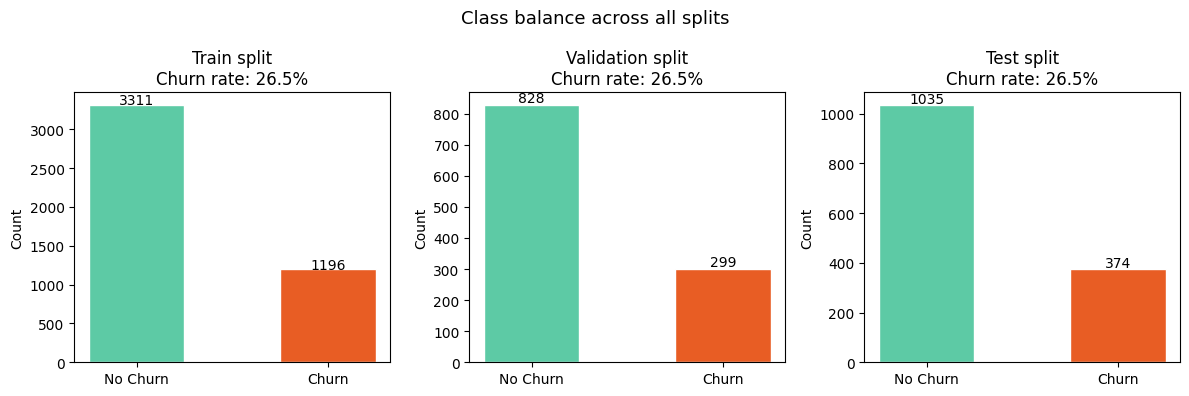

In [10]:
fig, axes = plt.subplots(1,3, figsize=(12,4))

splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]

for ax, (name, y_split) in zip(axes, splits):
    counts = y_split.value_counts()
    ax.bar(['No Churn', 'Churn'], 
           counts.values,
           color=["#5DCAA5", "#E85D24"], 
           width=0.5, 
           edgecolor="white")
    ax.set_title(f"{name} split\nChurn rate: {y_split.mean()*100:.1f}%")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha="center", fontsize=10)

plt.suptitle("Class balance across all splits", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/figures/05_split_balance.png", bbox_inches="tight")
plt.show()

## Phase 3 Summary

### Feature engineering
- Created `tenure_bin` (new / mid / loyal) based on EDA finding that churn
  drops sharply after 12 and 36 months. Churn rate: new=47.7%, mid=26.1%, loyal=6.2%.

### Preprocessing pipeline
| Column group | Columns | Transformation |
|---|---|---|
| Numeric | tenure, MonthlyCharges, TotalCharges | Impute(0) → StandardScaler |
| Binary | gender, SeniorCitizen, Partner, Dependents, PhoneService, PaperlessBilling | OrdinalEncoder |
| Categorical | Contract, InternetService, PaymentMethod, + 7 others + tenure_bin | OneHotEncoder |

### Data splits
| Split | Rows | % of total | Churn rate |
|---|---|---|---|
| Train | 4,507 | 64% | 26.5% |
| Validation | 1,127 | 16% | 26.5% |
| Test | 1,409 | 20% | 26.5% |

Stratified splitting preserved churn rate across all splits.

### Key files produced
- `models/preprocessor.pkl` — fitted sklearn ColumnTransformer
- `data/processed/X_train.npy` + y_train, X_val + y_val, X_test + y_test

### Next step
→ `03_modeling.ipynb` — train baseline, logistic regression, random forest,
  and XGBoost models. Compare on validation AUC-ROC.